# Compare GRU/LSTM Last-State vs All-States Models

This notebook compares the original recurrent models that use only the final hidden state against the new all-states variants. It reads:

- `../results_nonoverlap/` for the existing last-state GRU/LSTM results
- `../results_allstates/` for the new all-states GRU/LSTM results

It compares both standard overlapping test metrics and non-overlapping test-block metrics.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_LASTSTATE_DIR = Path("../results_nonoverlap")
RESULTS_ALLSTATES_DIR = Path("../results_allstates")
FIGURES_DIR = Path("../figures_allstates")
RESULTS_OUT_DIR = Path("../results_allstates")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Last-state results:", RESULTS_LASTSTATE_DIR.resolve())
print("All-states results:", RESULTS_ALLSTATES_DIR.resolve())

Last-state results: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_nonoverlap
All-states results: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_allstates


In [2]:
ARCHITECTURES = ["gru", "lstm"]
FEATURE_SETS = ["baseline", "physics"]
EVAL_TYPES = [
    ("standard_overlap", "standard_overlap_metrics.csv"),
    ("nonoverlap", "nonoverlap_test_metrics.csv"),
]

LASTSTATE_NAMES = {
    "gru": "gru_direct",
    "lstm": "lstm_direct",
}
ALLSTATES_NAMES = {
    "gru": "gru_allstates",
    "lstm": "lstm_allstates",
}

INPUT_LENGTH = 50
PREDICTION_HORIZON = 50
STRIDE = 5

def metric_file(base_dir, model_prefix, feature_set, suffix):
    model_name = f"{model_prefix}_{feature_set}_L{INPUT_LENGTH}_H{PREDICTION_HORIZON}_S{STRIDE}"
    return base_dir / f"{model_name}_{suffix}"

def load_metric_files():
    frames = []
    missing = []

    for architecture in ARCHITECTURES:
        for feature_set in FEATURE_SETS:
            for eval_type, suffix in EVAL_TYPES:
                specs = [
                    ("last_state", RESULTS_LASTSTATE_DIR, LASTSTATE_NAMES[architecture]),
                    ("all_states", RESULTS_ALLSTATES_DIR, ALLSTATES_NAMES[architecture]),
                ]
                for variant, base_dir, prefix in specs:
                    path = metric_file(base_dir, prefix, feature_set, suffix)
                    if not path.exists():
                        missing.append(str(path))
                        continue
                    df = pd.read_csv(path)
                    df["architecture"] = architecture.upper()
                    df["feature_set"] = feature_set
                    df["state_usage"] = variant
                    df["eval_type"] = eval_type
                    df["source_file"] = str(path)
                    frames.append(df)

    if missing:
        print("Missing files:")
        for m in missing:
            print(" -", m)

    if not frames:
        raise FileNotFoundError("No metric files found. Run the all-states notebooks first.")

    return pd.concat(frames, ignore_index=True)

metrics_df = load_metric_files()
combined_path = RESULTS_OUT_DIR / "combined_laststate_allstates_metrics.csv"
metrics_df.to_csv(combined_path, index=False)
print("Saved:", combined_path.resolve())
metrics_df.head()

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_allstates/combined_laststate_allstates_metrics.csv


,split,output,MSE,RMSE,MAE,NMAE_std,NRMSE_std,Relative_MAE_mean_abs,R2,true_mean_abs,true_std,architecture,feature_set,state_usage,eval_type,source_file
0,val_overlap_stride5,SEI growth rate [nm/s],7.798243e-07,0.000883,0.000551,0.273831,0.439257,0.240118,0.807053,0.002293,0.002010,GRU,baseline,last_state,standard_overlap,../results_nonoverlap/gru_direct_baseline_L50_...
1,val_overlap_stride5,Negative SEI thickness [nm],6.045331e+03,77.751724,52.839252,0.499736,0.735350,0.283624,0.459261,186.300520,105.734330,GRU,baseline,last_state,standard_overlap,../results_nonoverlap/gru_direct_baseline_L50_...
2,val_overlap_stride5,Cell temperature [K],1.403566e-02,0.118472,0.060909,0.159552,0.310342,0.000204,0.903688,298.089080,0.381747,GRU,baseline,last_state,standard_overlap,../results_nonoverlap/gru_direct_baseline_L50_...
3,test_overlap_stride5,SEI growth rate [nm/s],4.221433e-07,0.000650,0.000363,0.170362,0.304565,0.148820,0.907240,0.002442,0.002133,GRU,baseline,last_state,standard_overlap,../results_nonoverlap/gru_direct_baseline_L50_...
4,test_overlap_stride5,Negative SEI thickness [nm],2.680795e+03,51.776390,30.610167,0.342225,0.578865,0.202942,0.664915,150.831880,89.444664,GRU,baseline,last_state,standard_overlap,../results_nonoverlap/gru_direct_baseline_L50_...


In [3]:
# Mean NMAE across the three outputs
mean_nmae = (
    metrics_df
    .groupby(["architecture", "feature_set", "state_usage", "eval_type"], as_index=False)["NMAE_std"]
    .mean()
    .rename(columns={"NMAE_std": "mean_NMAE_std"})
)

mean_path = RESULTS_OUT_DIR / "laststate_vs_allstates_mean_nmae.csv"
mean_nmae.to_csv(mean_path, index=False)
print("Saved:", mean_path.resolve())
mean_nmae

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_allstates/laststate_vs_allstates_mean_nmae.csv


,architecture,feature_set,state_usage,eval_type,mean_NMAE_std
0,GRU,baseline,all_states,nonoverlap,0.239650
1,GRU,baseline,all_states,standard_overlap,0.274804
2,GRU,baseline,last_state,nonoverlap,0.216690
3,GRU,baseline,last_state,standard_overlap,0.263949
4,GRU,physics,all_states,nonoverlap,0.130882
5,GRU,physics,all_states,standard_overlap,0.100270
6,GRU,physics,last_state,nonoverlap,0.112249
7,GRU,physics,last_state,standard_overlap,0.088015
8,LSTM,baseline,all_states,nonoverlap,0.220100
9,LSTM,baseline,all_states,standard_overlap,0.263686


In [4]:
# Pivot table for quick reading
pivot = mean_nmae.pivot_table(
    index=["architecture", "feature_set", "eval_type"],
    columns="state_usage",
    values="mean_NMAE_std"
).reset_index()

if "all_states" in pivot.columns and "last_state" in pivot.columns:
    pivot["delta_all_minus_last"] = pivot["all_states"] - pivot["last_state"]
    pivot["percent_change"] = 100 * pivot["delta_all_minus_last"] / pivot["last_state"]

pivot_path = RESULTS_OUT_DIR / "laststate_vs_allstates_mean_nmae_delta.csv"
pivot.to_csv(pivot_path, index=False)
print("Saved:", pivot_path.resolve())
pivot

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_allstates/laststate_vs_allstates_mean_nmae_delta.csv


state_usage,architecture,feature_set,eval_type,all_states,last_state,delta_all_minus_last,percent_change
0,GRU,baseline,nonoverlap,0.239650,0.216690,0.022960,10.595630
1,GRU,baseline,standard_overlap,0.274804,0.263949,0.010855,4.112412
2,GRU,physics,nonoverlap,0.130882,0.112249,0.018632,16.599218
3,GRU,physics,standard_overlap,0.100270,0.088015,0.012255,13.923794
4,LSTM,baseline,nonoverlap,0.220100,0.224966,-0.004865,-2.162749
5,LSTM,baseline,standard_overlap,0.263686,0.270407,-0.006721,-2.485546
6,LSTM,physics,nonoverlap,0.112616,0.155455,-0.042838,-27.556842
7,LSTM,physics,standard_overlap,0.094466,0.117171,-0.022705,-19.377878


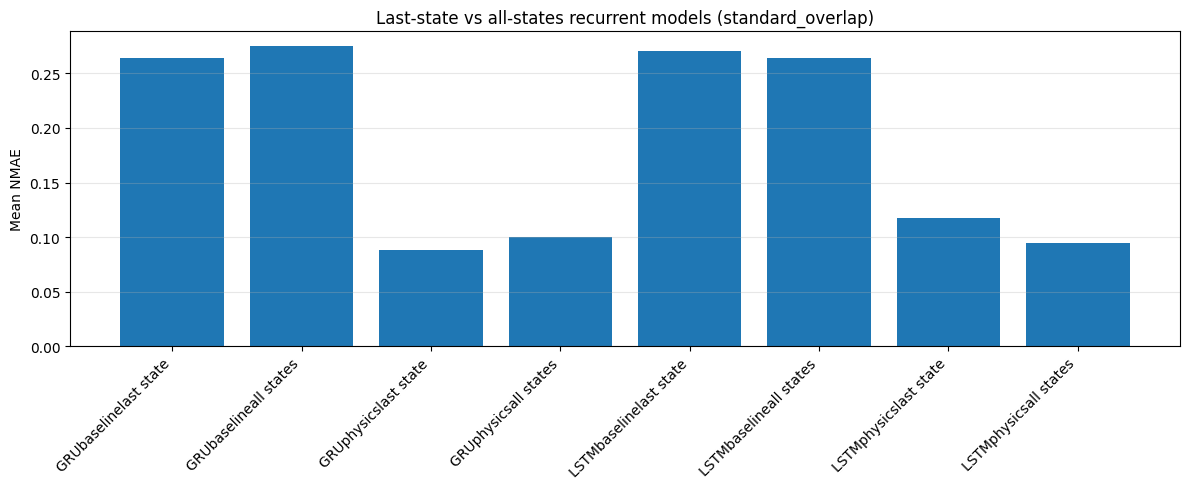

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_allstates/compare_laststate_allstates_mean_nmae_standard_overlap.png


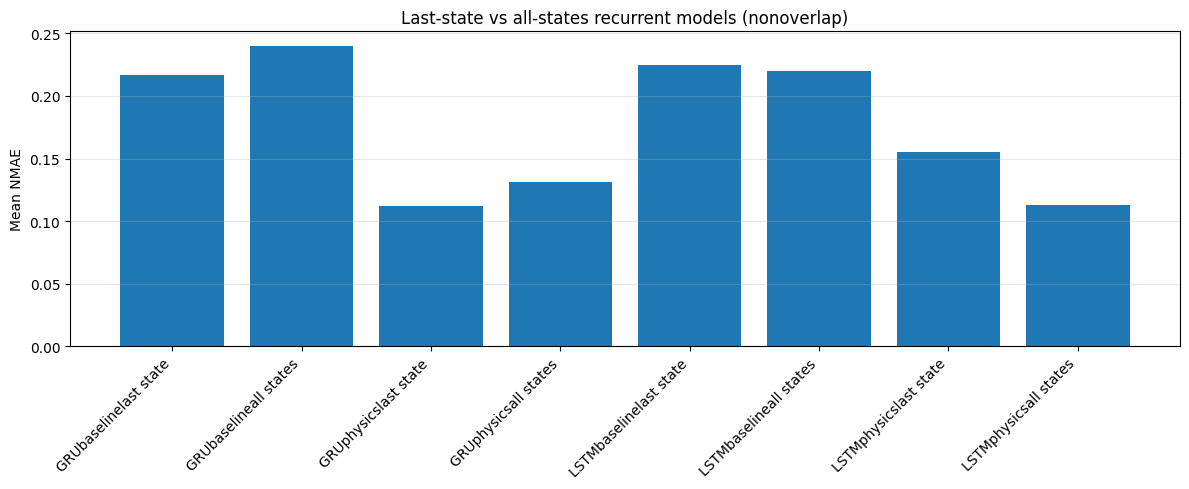

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_allstates/compare_laststate_allstates_mean_nmae_nonoverlap.png


In [6]:
# Plot mean NMAE for standard overlap and non-overlap evaluations.
for eval_type in ["standard_overlap", "nonoverlap"]:
    temp = mean_nmae[mean_nmae["eval_type"] == eval_type].copy()
    labels = []
    values = []

    for architecture in ARCHITECTURES:
        for feature_set in FEATURE_SETS:
            for state_usage in ["last_state", "all_states"]:
                row = temp[
                    (temp["architecture"] == architecture.upper()) &
                    (temp["feature_set"] == feature_set) &
                    (temp["state_usage"] == state_usage)
                ]
                if len(row) == 0:
                    continue
                labels.append(f"{architecture.upper()}{feature_set}{state_usage.replace('_', ' ')}")
                values.append(float(row["mean_NMAE_std"].iloc[0]))

    plt.figure(figsize=(12, 5))
    plt.bar(range(len(values)), values)
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.ylabel("Mean NMAE")
    plt.title(f"Last-state vs all-states recurrent models ({eval_type})")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    fig_path = FIGURES_DIR / f"compare_laststate_allstates_mean_nmae_{eval_type}.png"
    plt.savefig(fig_path, dpi=200)
    plt.show()
    print("Saved:", fig_path.resolve())

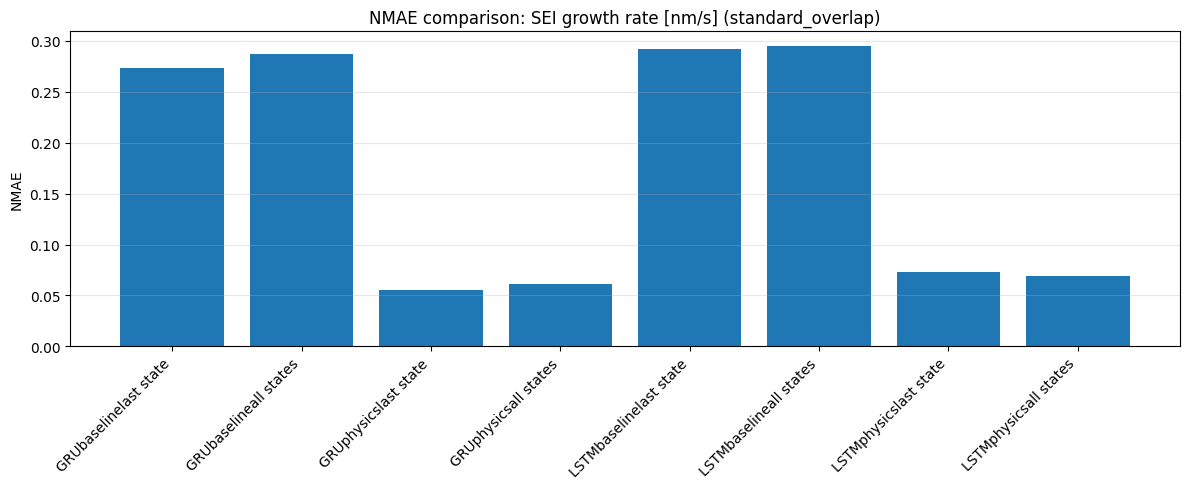

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_allstates/compare_laststate_allstates_nmae_standard_overlap_SEI_growth_rate_nm_per_s.png


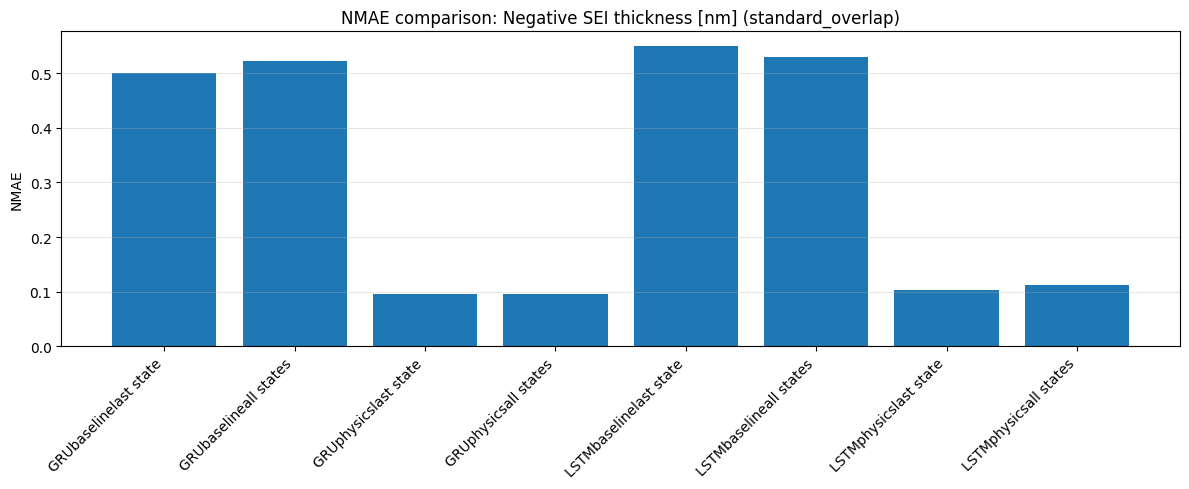

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_allstates/compare_laststate_allstates_nmae_standard_overlap_Negative_SEI_thickness_nm.png


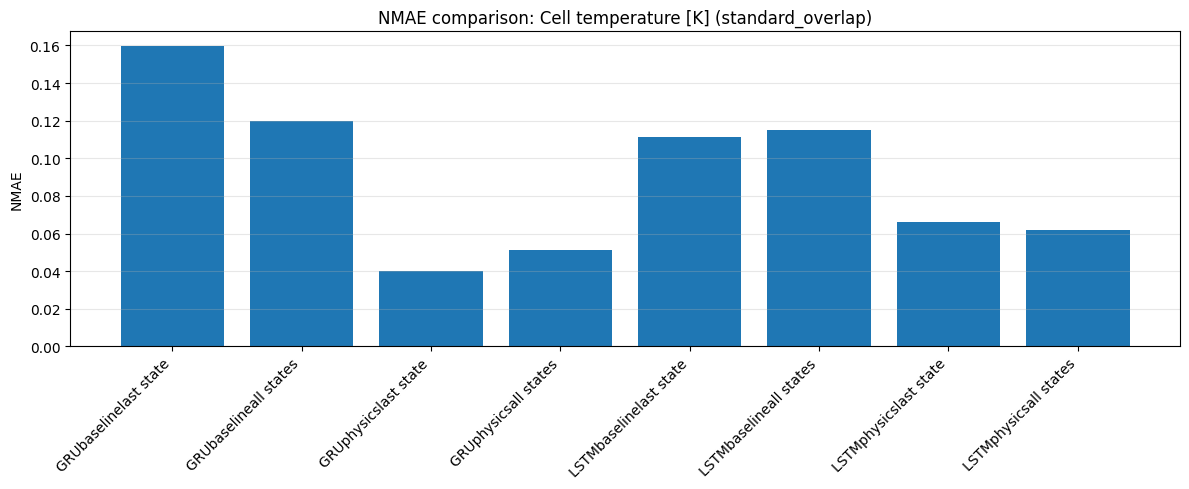

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_allstates/compare_laststate_allstates_nmae_standard_overlap_Cell_temperature_K.png


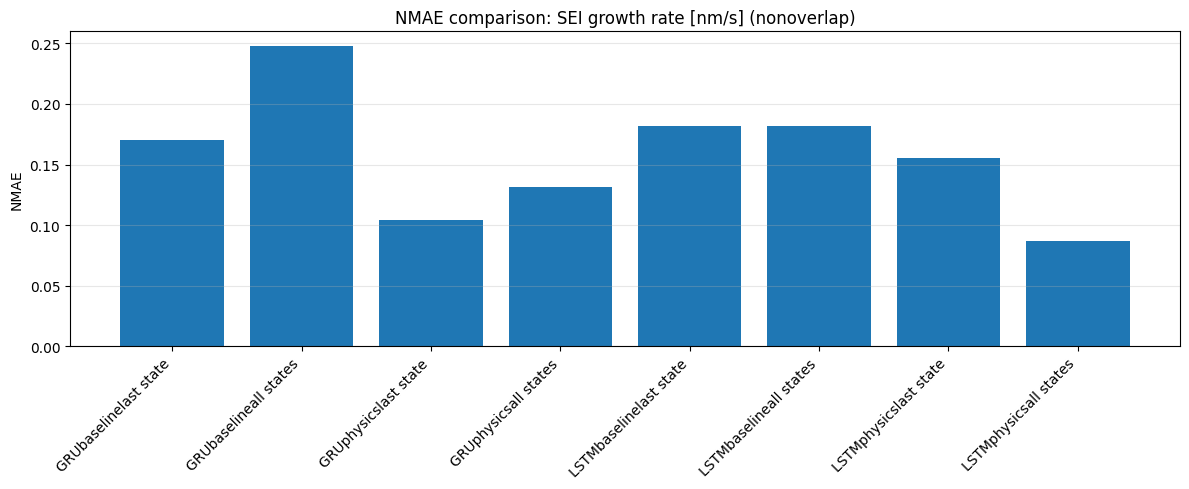

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_allstates/compare_laststate_allstates_nmae_nonoverlap_SEI_growth_rate_nm_per_s.png


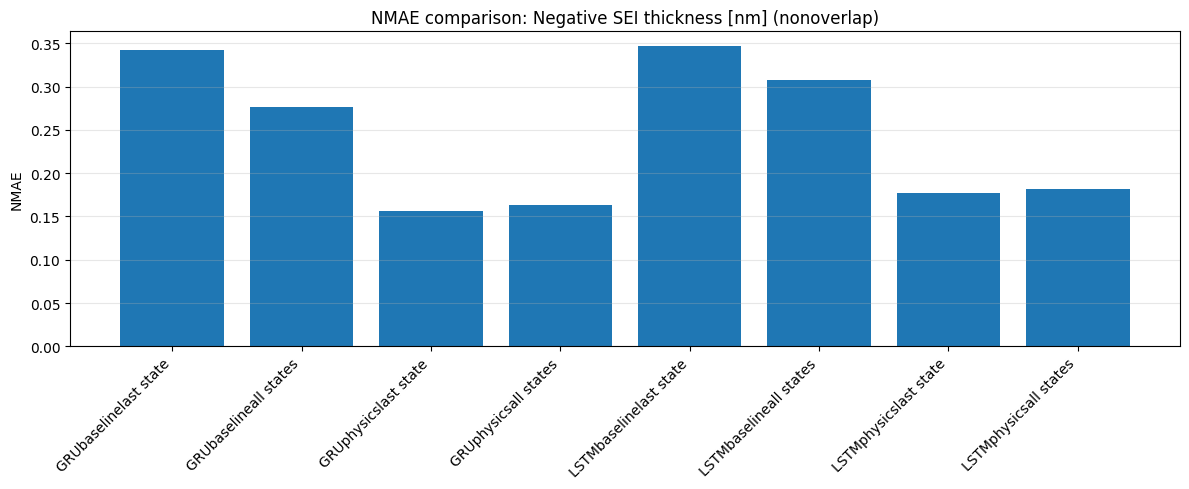

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_allstates/compare_laststate_allstates_nmae_nonoverlap_Negative_SEI_thickness_nm.png


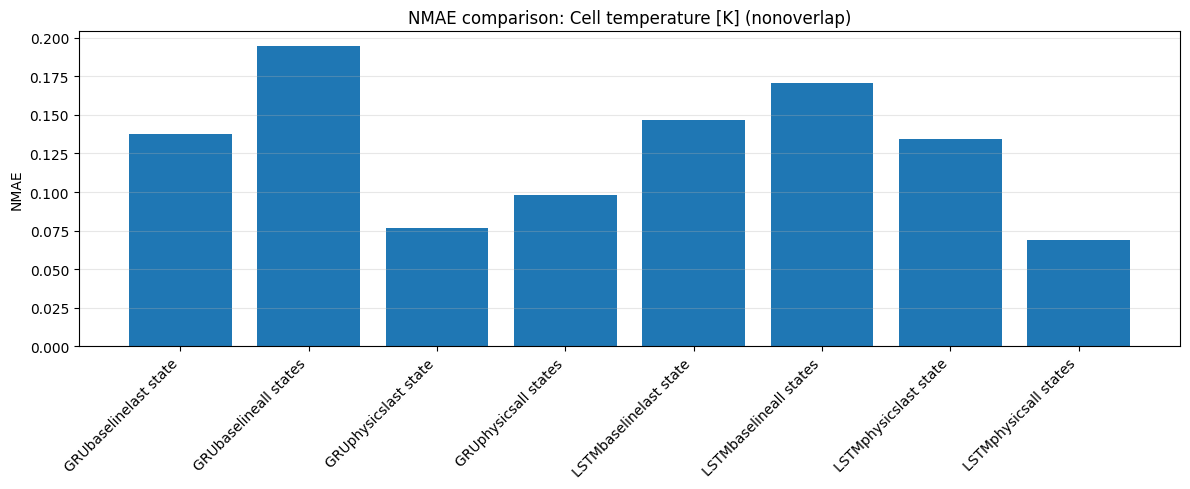

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_allstates/compare_laststate_allstates_nmae_nonoverlap_Cell_temperature_K.png


In [9]:
# Output-wise comparison using NMAE
for eval_type in ["standard_overlap", "nonoverlap"]:
    for output in metrics_df["output"].unique():
        temp = metrics_df[(metrics_df["eval_type"] == eval_type) & (metrics_df["output"] == output)]
        labels = []
        values = []

        for architecture in ARCHITECTURES:
            for feature_set in FEATURE_SETS:
                for state_usage in ["last_state", "all_states"]:
                    row = temp[
                        (temp["architecture"] == architecture.upper()) &
                        (temp["feature_set"] == feature_set) &
                        (temp["state_usage"] == state_usage)
                    ]
                    if len(row) == 0:
                        continue
                    labels.append(f"{architecture.upper()}{feature_set}{state_usage.replace('_', ' ')}")
                    values.append(float(row["NMAE_std"].iloc[0]))

        safe_output = (
            output.replace(" ", "_")
            .replace("[", "")
            .replace("]", "")
            .replace("/", "_per_")
            .replace(".", "")
        )

        plt.figure(figsize=(12, 5))
        plt.bar(range(len(values)), values)
        plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
        plt.ylabel("NMAE")
        plt.title(f"NMAE comparison: {output} ({eval_type})")
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()

        fig_path = FIGURES_DIR / f"compare_laststate_allstates_nmae_{eval_type}_{safe_output}.png"
        plt.savefig(fig_path, dpi=200)
        plt.show()
        print("Saved:", fig_path.resolve())

In [ ]:
# Load physical violation files, if available.
def load_violation_files():
    frames = []
    missing = []
    for architecture in ARCHITECTURES:
        for feature_set in FEATURE_SETS:
            for eval_type, suffix in [
                ("standard_overlap", "standard_overlap_physical_violations.csv"),
                ("nonoverlap", "nonoverlap_physical_violations.csv"),
            ]:
                specs = [
                    ("last_state", RESULTS_LASTSTATE_DIR, LASTSTATE_NAMES[architecture]),
                    ("all_states", RESULTS_ALLSTATES_DIR, ALLSTATES_NAMES[architecture]),
                ]
                for variant, base_dir, prefix in specs:
                    path = metric_file(base_dir, prefix, feature_set, suffix)
                    if not path.exists():
                        missing.append(str(path))
                        continue
                    df = pd.read_csv(path)
                    df["architecture"] = architecture.upper()
                    df["feature_set"] = feature_set
                    df["state_usage"] = variant
                    df["eval_type"] = eval_type
                    frames.append(df)

    if missing:
        print("Missing violation files:")
        for m in missing[:10]:
            print(" -", m)
        if len(missing) > 10:
            print("...", len(missing) - 10, "more")

    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

violations_df = load_violation_files()
if len(violations_df):
    violation_path = RESULTS_OUT_DIR / "combined_laststate_allstates_physical_violations.csv"
    violations_df.to_csv(violation_path, index=False)
    print("Saved:", violation_path.resolve())
    display(violations_df)
else:
    print("No physical violation files found yet.")

In [ ]:
# Training history comparison, if available.
def load_history_files():
    frames = []
    missing = []
    for architecture in ARCHITECTURES:
        for feature_set in FEATURE_SETS:
            specs = [
                ("last_state", RESULTS_LASTSTATE_DIR, LASTSTATE_NAMES[architecture]),
                ("all_states", RESULTS_ALLSTATES_DIR, ALLSTATES_NAMES[architecture]),
            ]
            for variant, base_dir, prefix in specs:
                model_name = f"{prefix}_{feature_set}_L{INPUT_LENGTH}_H{PREDICTION_HORIZON}_S{STRIDE}"
                path = base_dir / f"{model_name}_history.csv"
                if not path.exists():
                    missing.append(str(path))
                    continue
                df = pd.read_csv(path)
                df["architecture"] = architecture.upper()
                df["feature_set"] = feature_set
                df["state_usage"] = variant
                frames.append(df)

    if missing:
        print("Missing history files:")
        for m in missing:
            print(" -", m)

    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

history_df = load_history_files()
if len(history_df):
    history_path = RESULTS_OUT_DIR / "combined_laststate_allstates_training_history.csv"
    history_df.to_csv(history_path, index=False)
    print("Saved:", history_path.resolve())
    display(history_df.head())
else:
    print("No history files found yet.")

In [ ]:
if len(history_df):
    for architecture in ["GRU", "LSTM"]:
        for feature_set in FEATURE_SETS:
            temp = history_df[(history_df["architecture"] == architecture) & (history_df["feature_set"] == feature_set)]
            if len(temp) == 0:
                continue
            plt.figure(figsize=(8, 4))
            for state_usage in ["last_state", "all_states"]:
                sub = temp[temp["state_usage"] == state_usage]
                if len(sub) == 0:
                    continue
                plt.plot(sub["epoch"], sub["val_loss"], label=f"{state_usage} val")
            plt.xlabel("Epoch")
            plt.ylabel("Validation loss")
            plt.title(f"Validation loss: {architecture} {feature_set}")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            fig_path = FIGURES_DIR / f"history_laststate_allstates_{architecture.lower()}_{feature_set}.png"
            plt.savefig(fig_path, dpi=200)
            plt.show()
            print("Saved:", fig_path.resolve())